LOGISTIC REGRESSION

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df=pd.read_csv(r"C:\Users\KSHITIJ\Downloads\weatherAUS-2.csv")
print("Logisitc Regression")
print("DATA PREPROCEESING")
print(df)

Logisitc Regression
DATA PREPROCEESING
              Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
142188  2017-06-20    Uluru      3.5     21.8       0.0          NaN   
142189  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
142190  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
142191  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
142192  2017-06-24    Uluru      7.8     27.0       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  \
0            NaN     

In [4]:
df2=df.copy()
print(df2)
df2.info

              Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
142188  2017-06-20    Uluru      3.5     21.8       0.0          NaN   
142189  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
142190  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
142191  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
142192  2017-06-24    Uluru      7.8     27.0       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  \
0            NaN           W           44.0          W  ... 

<bound method DataFrame.info of               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
142188  2017-06-20    Uluru      3.5     21.8       0.0          NaN   
142189  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
142190  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
142191  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
142192  2017-06-24    Uluru      7.8     27.0       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  \
0            NaN           W

In [5]:
print("missing values in the col")
print(df2.isnull().sum())
print("Rows with NaNs:\n", df2[df2.isna().any(axis=1)])

missing values in the col
Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64
Rows with NaNs:
               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     

In [6]:
df2.drop(columns=['Evaporation', 'Sunshine','Cloud9am','Cloud3pm'], inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   WindGustDir    132863 non-null  object 
 6   WindGustSpeed  132923 non-null  float64
 7   WindDir9am     132180 non-null  object 
 8   WindDir3pm     138415 non-null  object 
 9   WindSpeed9am   140845 non-null  float64
 10  WindSpeed3pm   139563 non-null  float64
 11  Humidity9am    140419 non-null  float64
 12  Humidity3pm    138583 non-null  float64
 13  Pressure9am    128179 non-null  float64
 14  Pressure3pm    128212 non-null  float64
 15  Temp9am        141289 non-null  float64
 16  Temp3pm        139467 non-null  float64
 17  RainToday      140787 non-nul

In [7]:
print(df2.isnull().sum())

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64


the cols that are categorical and have non-numerical values
WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow


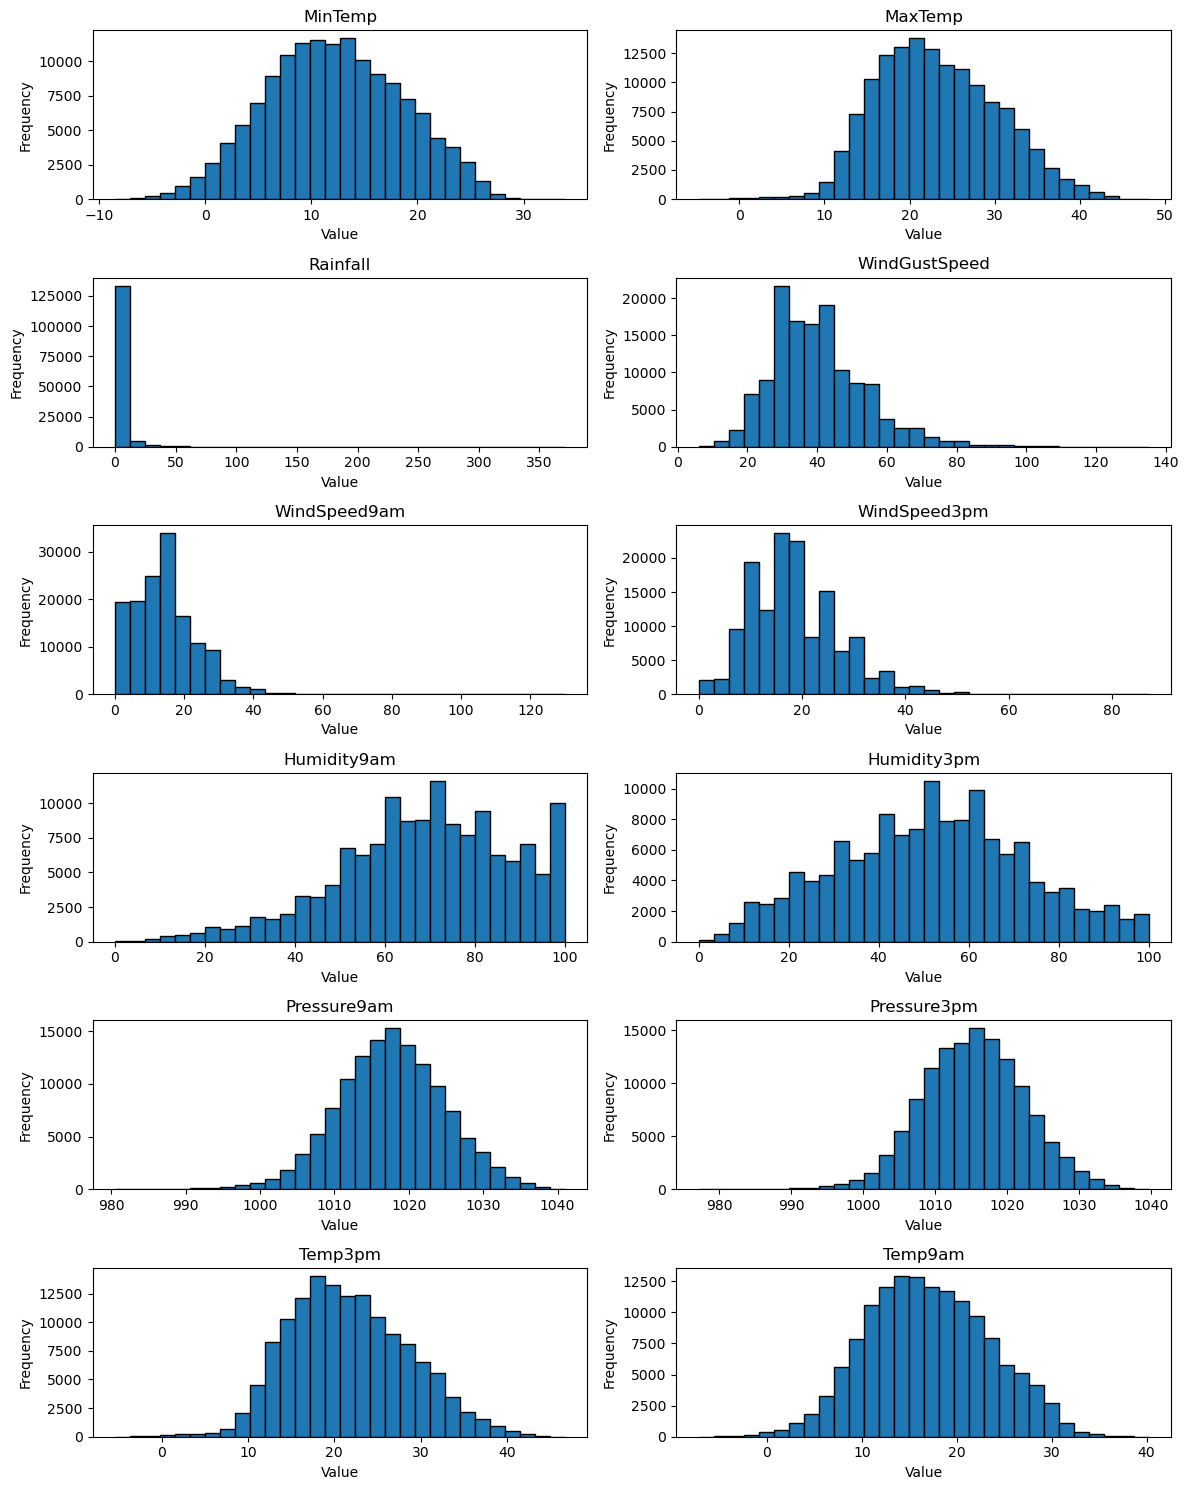

In [8]:
print("the cols that are categorical and have non-numerical values")
print("WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow")
col_to_plot = ["MinTemp", "MaxTemp", "Rainfall", "WindGustSpeed", "WindSpeed9am", 
               "WindSpeed3pm", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm","Temp3pm","Temp9am"]
dfnew = df[col_to_plot]
fig, axes = plt.subplots(6, 2, figsize=(12, 15))
axes = axes.flatten()
for idx, col in enumerate(col_to_plot):
    axes[idx].hist(dfnew[col], bins=30, edgecolor='black')
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


In [38]:
nonnum=["WindGustDir","WindDir9am","WindDir3pm","RainToday","RainTomorrow"]
for col in nonnum :
    df2[col] = df2[col].fillna(df2[col].mode()[0])
for col in col_to_plot : 
    df2[col] = df2[col].fillna(df2[col].mean())
print(df2.isnull().sum())


Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64


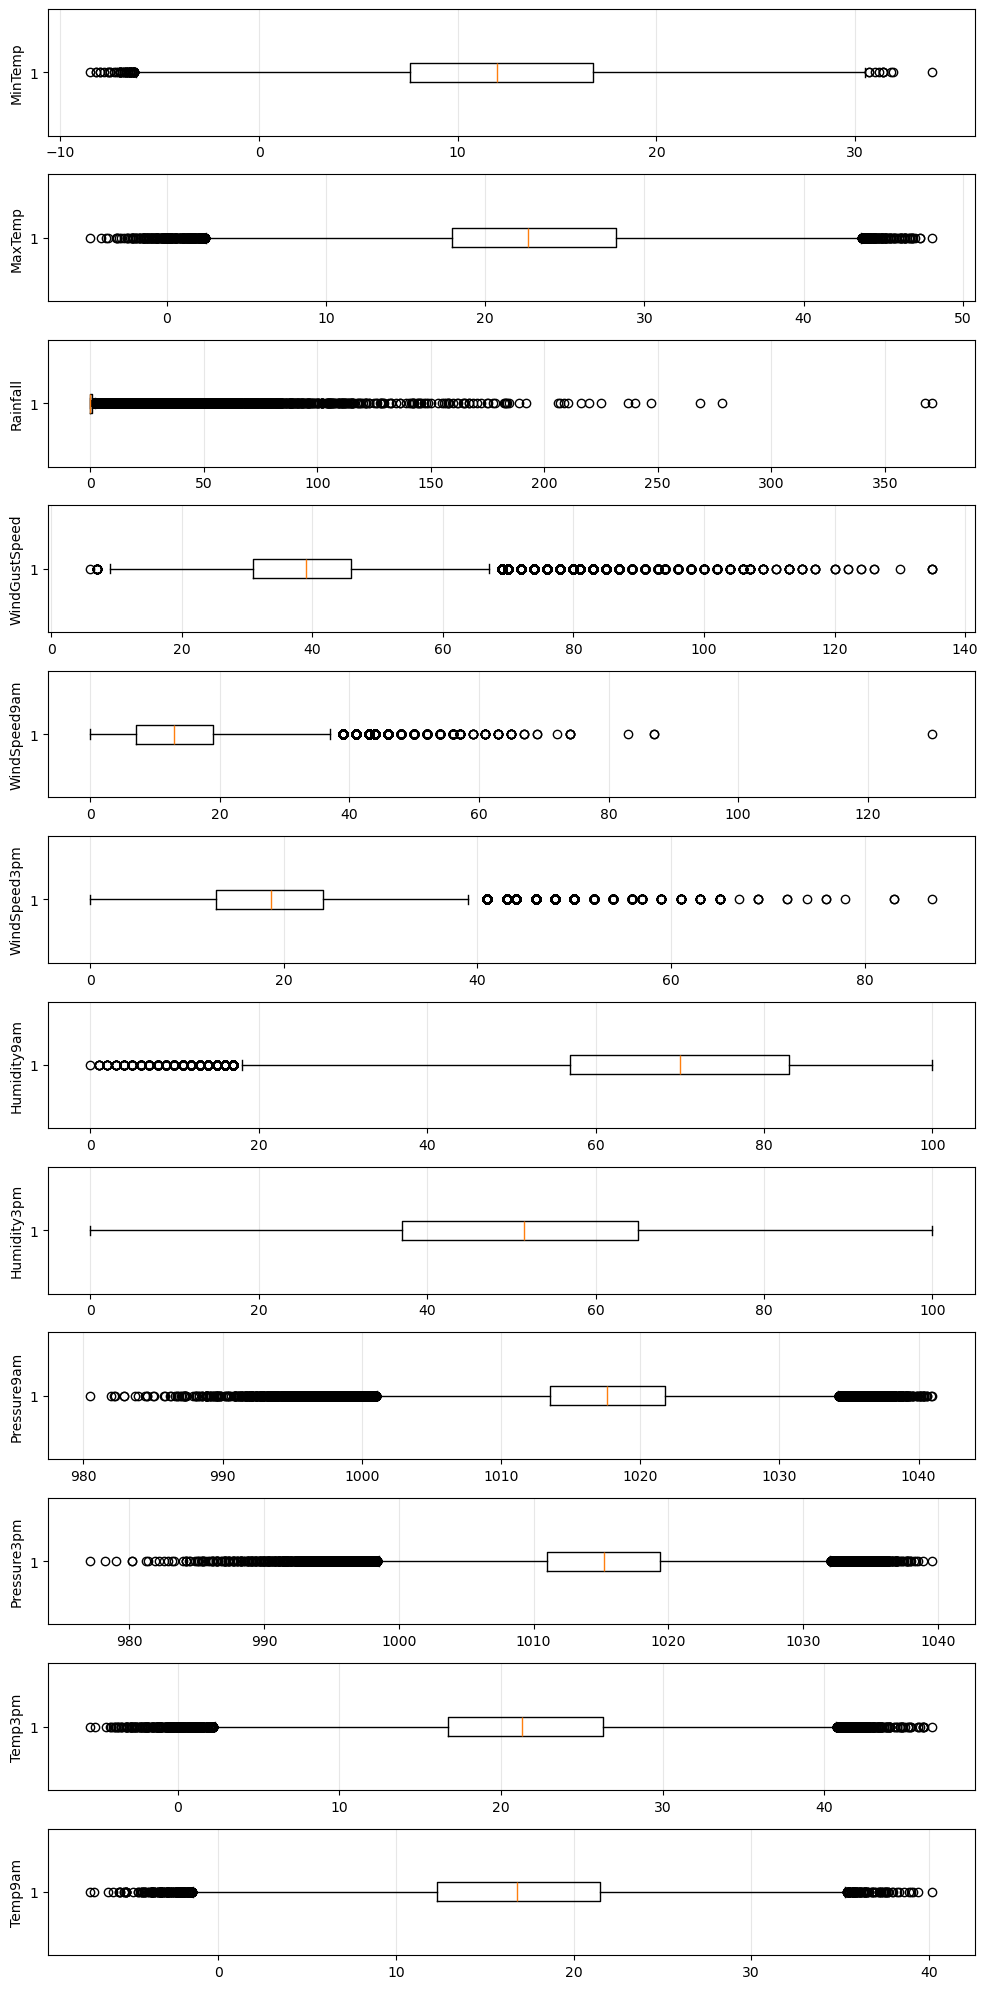

In [39]:
fig, axs = plt.subplots(len(col_to_plot), 1, figsize=(10, 20), dpi=100)
for i, col in enumerate(col_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
    axs[i].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import time
start_time = time.time()
clean_df=df2.copy()
Q1 = clean_df[col_to_plot].quantile(0.25)
Q3 = clean_df[col_to_plot].quantile(0.75)
IQR = Q3 - Q1
mask = ((clean_df[col_to_plot] >= Q1 - 1.5 * IQR) & 
        (clean_df[col_to_plot] <= Q3 + 1.5 * IQR)).all(axis=1)
clean_df = clean_df[mask]
df_new = clean_df[col_to_plot]
print("Shape after removing outliers:", clean_df.shape)
print(f"Time taken: {time.time() - start_time} seconds")
print(df_new.head())

Shape after removing outliers: (93134, 20)
Time taken: 0.19306087493896484 seconds
   MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  WindSpeed3pm  \
0     13.4     22.9       0.6           44.0          20.0          24.0   
1      7.4     25.1       0.0           44.0           4.0          22.0   
2     12.9     25.7       0.0           46.0          19.0          26.0   
3      9.2     28.0       0.0           24.0          11.0           9.0   
4     17.5     32.3       1.0           41.0           7.0          20.0   

   Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Temp3pm  Temp9am  
0         71.0         22.0       1007.7       1007.1     21.8     16.9  
1         44.0         25.0       1010.6       1007.8     24.3     17.2  
2         38.0         30.0       1007.6       1008.7     23.2     21.0  
3         45.0         16.0       1017.6       1012.8     26.5     18.1  
4         82.0         33.0       1010.8       1006.0     29.7     17.8  


In [13]:
df_new1=clean_df[col_to_plot]
df_normalized = (df_new1 - df_new1.min()) / (df_new1.max() - df_new1.min())
print(df_normalized)

         MinTemp   MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
0       0.538462  0.495122       0.3       0.575758      0.540541   
1       0.373626  0.548780       0.0       0.575758      0.108108   
2       0.524725  0.563415       0.0       0.606061      0.513514   
3       0.423077  0.619512       0.0       0.272727      0.297297   
4       0.651099  0.724390       0.5       0.530303      0.189189   
...          ...       ...       ...            ...           ...   
142188  0.266484  0.468293       0.0       0.378788      0.405405   
142189  0.247253  0.507317       0.0       0.378788      0.351351   
142190  0.269231  0.553659       0.0       0.242424      0.351351   
142191  0.318681  0.592683       0.0       0.469697      0.243243   
142192  0.384615  0.595122       0.0       0.333333      0.351351   

        WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  \
0           0.615385     0.646341     0.212121     0.237467     0.289062   
1           0.56410

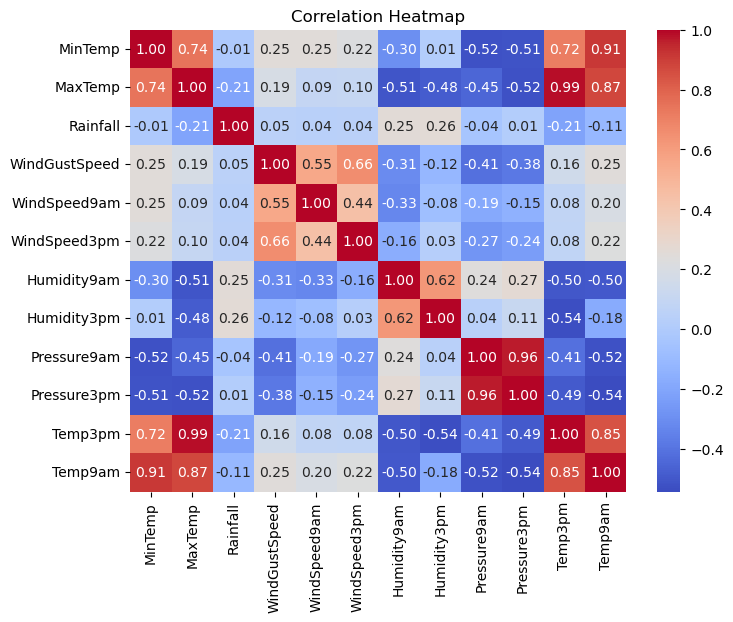

In [40]:
corr = df_normalized.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [41]:

print("LOGISTIC REGRESSION")
print(len(df2))#
print(len(df_normalized))
common_idx = df_normalized.index.intersection(df2.index)
#needed as the rows in df1 and df_normalized is not same so taking those which have smae index
df_norm = df_normalized.loc[common_idx]
df_target = df2.loc[common_idx]
x1 = df_norm['Humidity3pm'].values
x2 = (df_target['RainToday'] == 'Yes').astype(int)
x3 = df_norm['Humidity9am'].values
y = (df_target['RainTomorrow'] == 'Yes').astype(int)
print(f"Total samples: {len(x1)}")
split = int(0.7 * len(x1))
x1_train, x1_test = x1[:split], x1[split:]
x2_train, x2_test = x2[:split], x2[split:]
x3_train, x3_test = x3[:split], x3[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(x1_train)}, Test: {len(x1_test)}")

LOGISTIC REGRESSION
142193
93134
Total samples: 93134
Train: 65193, Test: 27941


In [42]:
print(df2['RainToday'].isnull().sum())
print(df2['RainTomorrow'].isnull().sum())

0
0


In [43]:
X_train = np.column_stack([np.ones(len(x1_train)), x1_train, x2_train, x3_train])
X_test = np.column_stack([np.ones(len(x1_test)), x1_test, x2_test, x3_test])

In [44]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

COST FUNCTION

In [45]:
theta = np.zeros(X_train.shape[1])
learning_rate = 0.1
iterations = 1000
costs = []

for i in range(iterations):
    pred = sigmoid(X_train @ theta)
    error = pred - y_train
    gradient = (X_train.T @ error) / len(y_train)
    theta -= learning_rate * gradient
    
    if i % 100 == 0:
        cost = -np.mean(y_train * np.log(pred + 1e-15) + (1 - y_train) * np.log(1 - pred + 1e-15))
        costs.append(cost)
        print(f"Iteration {i}, Cost: {cost:.4f}")

print("\nModel trained!")
print(f"Coefficients: {theta}")

Iteration 0, Cost: 0.6931
Iteration 100, Cost: 0.4562
Iteration 200, Cost: 0.4483
Iteration 300, Cost: 0.4420
Iteration 400, Cost: 0.4363
Iteration 500, Cost: 0.4312
Iteration 600, Cost: 0.4267
Iteration 700, Cost: 0.4226
Iteration 800, Cost: 0.4189
Iteration 900, Cost: 0.4156

Model trained!
Coefficients: [-2.13389827  1.27088889  0.5285321  -0.21541816]


In [46]:
z_train = X_train @ theta
prob_train = sigmoid(z_train)
y_pred_train = (prob_train >= 0.17).astype(int)

z_test = X_test @ theta
prob_test = sigmoid(z_test)
y_pred_test = (prob_test >= 0.17).astype(int)

train_acc = np.mean(y_pred_train == y_train)
test_acc = np.mean(y_pred_test == y_test)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nCoefficients:")
print(f"Intercept: {theta[0]:.4f}")
print(f"Humidity3pm: {theta[1]:.4f}")
print(f"RainToday: {theta[2]:.4f}")
print(f"Humidity9am: {theta[3]:.4f}")


Train Accuracy: 0.6456
Test Accuracy: 0.7475

Coefficients:
Intercept: -2.1339
Humidity3pm: 1.2709
RainToday: 0.5285
Humidity9am: -0.2154


In [47]:
import numpy as np
tn = np.sum((y_pred_test == 0) & (y_test == 0))
fp = np.sum((y_pred_test == 1) & (y_test == 0))
fn = np.sum((y_pred_test == 0) & (y_test == 1))
tp = np.sum((y_pred_test == 1) & (y_test == 1))
cm = np.array([[tn, fp], [fn, tp]])

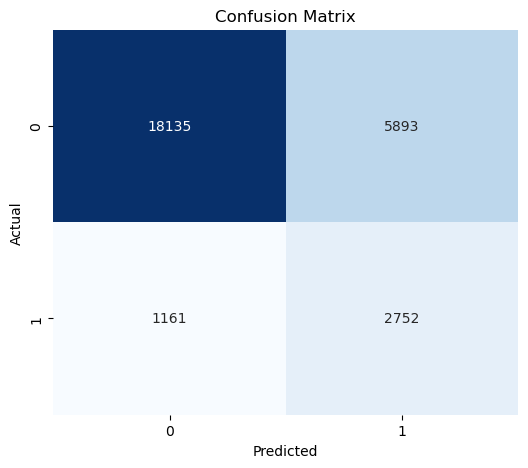

In [50]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

0.3183342972816657
0.7032967032967034
0.43828635132982957

AUC (Area Under Curve): -0.7959


C:\Users\KSHITIJ\AppData\Local\Temp\ipykernel_17292\711068133.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_list, fpr_list)


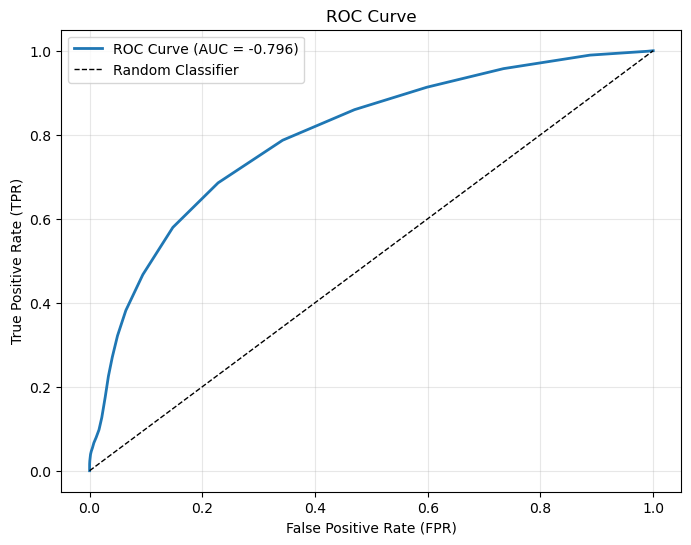

In [49]:
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(precision)
print(recall)
print(f1)
thresholds = np.linspace(0, 1, 100)
tpr_list = []
fpr_list = []

for threshold in thresholds:
    y_pred_threshold = (prob_test >= threshold).astype(int)
    
    tp_t = np.sum((y_pred_threshold == 1) & (y_test == 1))
    fn_t = np.sum((y_pred_threshold == 0) & (y_test == 1))
    fp_t = np.sum((y_pred_threshold == 1) & (y_test == 0))
    tn_t = np.sum((y_pred_threshold == 0) & (y_test == 0))
    
    tpr = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    fpr = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)
auc = np.trapz(tpr_list, fpr_list)
print(f"\nAUC (Area Under Curve): {auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

